# 04 — Model Rankings & Bucket-Specific Finetuning

Analyses:
1. Overall model rankings — no-finetune global baseline
2. Bucket-specific finetuning: regime-specialised global models per feature tercile
   (Low / Medium / High), each trained and evaluated exclusively on its own bucket
3. Linear vs non-linear model split
4. Interaction with STL decomposition
5. Per-feature analysis
6. Statistical significance (Wilcoxon + Holm)

> **Design:** For each task (feature × freq × decomp × model), three specialised
> global models are trained — one on ~250 Low-bucket series, one on ~250 Medium,
> one on ~250 High. Each is evaluated only on its own bucket's test series.
> `rn_delta_ft > 0` means the bucket-specialised model beats the global baseline.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
DATA = Path("data")

master    = pd.read_parquet(DATA / "master_metrics.parquet")
bkt_delta = pd.read_parquet(DATA / "bucket_ft_delta.parquet")

DECOMP_LABELS = {
    "without_stl": "Direct",
    "stl_seasonal_naive": "STL-SN",
    "stl_model_all_components": "STL-AC",
}
FAMILY_LABELS = {
    "statistical": "Statistical",
    "mlforecast": "ML",
    "neuralforecast": "Neural",
    "transformers": "Transformer",
}
BUCKET_PALETTE = {"Low": "#4878D0", "Medium": "#EE854A", "High": "#6ACC65"}
LINEAR_MODELS = {"AutoRidge", "AutoLinearRegression", "AutoNLinear"}

bkt_delta["model_type"] = bkt_delta["model_name"].apply(
    lambda m: "Linear" if m in LINEAR_MODELS else "Non-linear")

print("Master finetuning modes:")
print(master["finetuning_mode"].value_counts().to_string())
print(f"\nBucket-finetune delta rows: {len(bkt_delta):,}")


Master finetuning modes:
finetuning_mode
no_finetune               1932984
finetune_bucket_low        610119
finetune_bucket_high       434889
finetune_bucket_medium     404730

Bucket-finetune delta rows: 1,449,738


## 1  Overall Model Rankings — No-Finetune Baseline

In [2]:
baseline = master[master["finetuning_mode"] == "no_finetune"].copy()
rn_rank = (
    baseline
    .groupby(["model_family","model_name","decomposition_method"], as_index=False)
    .agg(mean_rn=("rel_naive_clipped","mean"),
         median_rn=("rel_naive_clipped","median"),
         n=("rel_naive_clipped","count"))
    .sort_values("mean_rn")
    .reset_index(drop=True)
)
rn_rank.insert(0,"rank", rn_rank.index+1)
rn_rank["decomp"] = rn_rank["decomposition_method"].map(DECOMP_LABELS)
rn_rank["family"] = rn_rank["model_family"].map(FAMILY_LABELS)
print("Top 15 by mean RelNaive (lower = better):")
print(rn_rank[["rank","family","model_name","decomp","mean_rn","median_rn"]].head(15).to_string(index=False))
rn_rank.to_csv(DATA / "table_rn_ranking_baseline.csv", index=False)


Top 15 by mean RelNaive (lower = better):
 rank      family           model_name decomp  mean_rn  median_rn
    1 Statistical              AutoETS Direct 0.888421   0.791368
    2 Statistical            AutoARIMA STL-SN 0.930381   0.887241
    3      Neural          AutoNLinear STL-SN 0.930591   0.888469
    4 Statistical           AutoSARIMA STL-SN 0.930986   0.889241
    5          ML AutoLinearRegression STL-SN 0.932717   0.892505
    6          ML            AutoRidge STL-SN 0.932771   0.889376
    7 Transformer         AutoPatchTST STL-SN 0.933424   0.890679
    8 Statistical              AutoETS STL-SN 0.934834   0.918401
    9 Transformer         AutoPatchTST STL-AC 0.935668   0.826444
   10 Transformer              AutoTFT STL-SN 0.935720   0.918881
   11      Neural          AutoNLinear STL-AC 0.936657   0.828706
   12          ML            AutoRidge STL-AC 0.937404   0.831929
   13 Statistical           AutoSARIMA STL-AC 0.937460   0.830451
   14 Statistical            AutoA

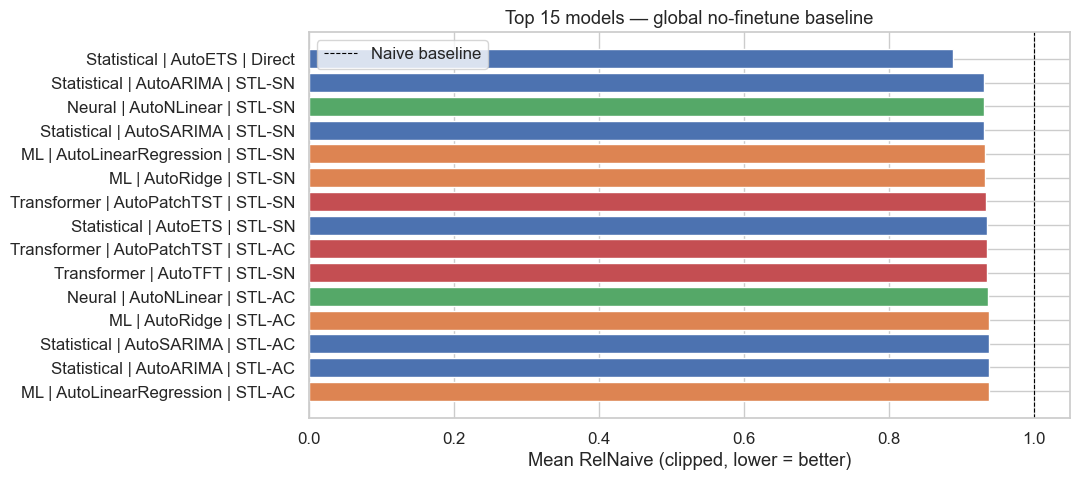

In [3]:
fig, ax = plt.subplots(figsize=(11,5))
top15 = rn_rank.head(15).copy()
top15["label"] = top15["family"] + " | " + top15["model_name"] + " | " + top15["decomp"]
family_colors = {"Statistical":"#4C72B0","ML":"#DD8452","Neural":"#55A868","Transformer":"#C44E52"}
colors = [family_colors.get(f,"gray") for f in top15["family"]]
ax.barh(top15["label"][::-1], top15["mean_rn"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(1.0, color="black", lw=0.8, ls="--", label="Naive baseline")
ax.set_xlabel("Mean RelNaive (clipped, lower = better)")
ax.set_title("Top 15 models — global no-finetune baseline")
ax.legend()
fig.tight_layout()
plt.savefig(DATA / "fig_rn_ranking_baseline.png", dpi=150, bbox_inches="tight")
plt.show()


## 2  Bucket-Specific Finetuning — Overall Results

In [4]:
summary = (
    bkt_delta
    .groupby(["trained_on_bucket","model_family"])["rn_delta_ft"]
    .agg(mean="mean", median="median",
         win_rate=lambda x:(x>0).mean(), n="count")
    .round(4).reset_index()
)
summary["model_family"] = summary["model_family"].map(FAMILY_LABELS)
print("Delta by bucket × family (positive = bucket model beats global baseline):")
print(summary.to_string(index=False))
summary.to_csv(DATA / "table_bucket_ft_summary.csv", index=False)

d = bkt_delta["rn_delta_ft"]
print(f"\nOverall: median={d.median():+.4f}  mean={d.mean():+.4f}  win={(d>0).mean()*100:.1f}%  n={len(d):,}")


Delta by bucket × family (positive = bucket model beats global baseline):
trained_on_bucket model_family    mean  median  win_rate      n
             High           ML -0.0782  0.0540    0.5560 193284
             High       Neural  0.0404  0.0461    0.5623 144963
             High  Transformer -0.0442  0.0349    0.5560  96642
              Low           ML -0.0761  0.0627    0.5640 271164
              Low       Neural  0.0202  0.0466    0.5560 203373
              Low  Transformer -0.0506  0.0294    0.5467 135582
           Medium           ML -0.0448  0.0783    0.5764 179880
           Medium       Neural  0.0473  0.0581    0.5695 134910
           Medium  Transformer -0.0348  0.0337    0.5504  89940

Overall: median=+0.0504  mean=-0.0288  win=56.1%  n=1,449,738


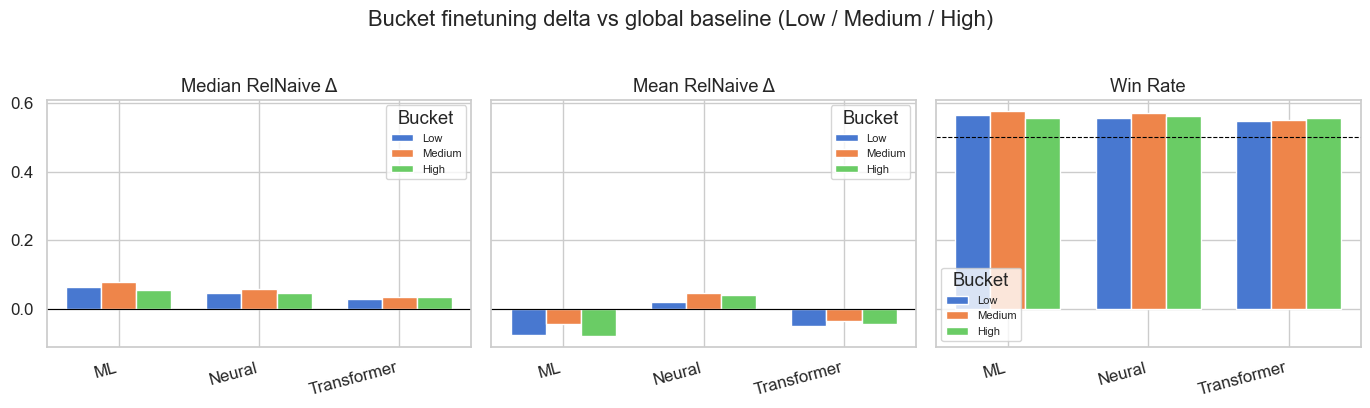

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14,4), sharey=True)
metrics = [("median","Median RelNaive Δ"), ("mean","Mean RelNaive Δ"), ("win_rate","Win Rate")]
for ax, (metric, label) in zip(axes, metrics):
    pivot = summary.pivot(index="model_family", columns="trained_on_bucket", values=metric)
    pivot = pivot.reindex(columns=["Low","Medium","High"])
    x = np.arange(len(pivot)); w = 0.25
    for i, bk in enumerate(["Low","Medium","High"]):
        ax.bar(x+i*w, pivot[bk].values, w, label=bk, color=BUCKET_PALETTE[bk], edgecolor="white")
    ax.axhline(0 if metric!="win_rate" else 0.5, color="black", lw=0.8,
               ls="--" if metric=="win_rate" else "-")
    ax.set_xticks(x+w); ax.set_xticklabels(pivot.index, rotation=15, ha="right")
    ax.set_title(label); ax.legend(title="Bucket", fontsize=8)
fig.suptitle("Bucket finetuning delta vs global baseline (Low / Medium / High)", y=1.02)
fig.tight_layout()
plt.savefig(DATA / "fig_bucket_ft_by_family.png", dpi=150, bbox_inches="tight")
plt.show()


## 3  Linear vs Non-Linear Models

Non-linear models extract regime-specific patterns from ~250 bucket series.
Linear models overfit to the small training set and are consistently harmed.


model_type model_family    mean  median  win_rate      n
    Linear           ML -0.3272 -0.0032    0.4959 322164
    Linear       Neural -0.0987 -0.0289    0.4509 161082
Non-linear           ML  0.1912  0.1722    0.6342 322164
Non-linear       Neural  0.1001  0.1127    0.6171 322164
Non-linear  Transformer -0.0443  0.0322    0.5505 322164


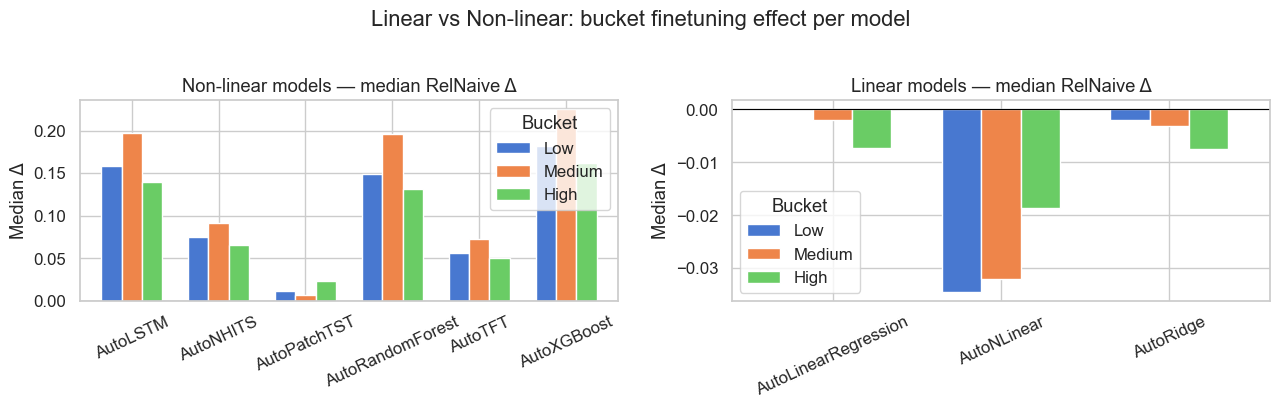

In [6]:
lin_summary = (
    bkt_delta.groupby(["model_type","model_family"])["rn_delta_ft"]
    .agg(mean="mean", median="median", win_rate=lambda x:(x>0).mean(), n="count")
    .round(4).reset_index()
)
lin_summary["model_family"] = lin_summary["model_family"].map(FAMILY_LABELS)
print(lin_summary.to_string(index=False))

fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, mtype in zip(axes, ["Non-linear","Linear"]):
    sub = bkt_delta[bkt_delta["model_type"]==mtype]
    grp = sub.groupby(["trained_on_bucket","model_name"])["rn_delta_ft"].median().reset_index()
    pivot = grp.pivot(index="model_name",columns="trained_on_bucket",values="rn_delta_ft")
    pivot = pivot.reindex(columns=["Low","Medium","High"])
    pivot.plot(kind="bar", ax=ax, color=[BUCKET_PALETTE[b] for b in pivot.columns],
               edgecolor="white", width=0.7)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{mtype} models — median RelNaive Δ")
    ax.set_xlabel(""); ax.set_ylabel("Median Δ")
    ax.tick_params(axis="x", rotation=25); ax.legend(title="Bucket")
fig.suptitle("Linear vs Non-linear: bucket finetuning effect per model", y=1.02)
fig.tight_layout()
plt.savefig(DATA / "fig_bucket_ft_linear_vs_nonlinear.png", dpi=150, bbox_inches="tight")
plt.show()


## 4  Top and Bottom Model × Bucket Combinations

In [7]:
top_combos = (
    bkt_delta
    .groupby(["model_family","model_name","trained_on_bucket","decomposition_method"])["rn_delta_ft"]
    .agg(mean="mean", median="median", win_rate=lambda x:(x>0).mean(), n="count")
    .reset_index().sort_values("median", ascending=False)
)
top_combos["family"] = top_combos["model_family"].map(FAMILY_LABELS)
top_combos["decomp"] = top_combos["decomposition_method"].map(DECOMP_LABELS)
cols = ["family","model_name","trained_on_bucket","decomp","mean","median","win_rate","n"]
print("TOP 15 (best median):")
print(top_combos[cols].head(15).round(4).to_string(index=False))
print("\nBOTTOM 10 (most harmed):")
print(top_combos[cols].tail(10).round(4).to_string(index=False))
top_combos.to_csv(DATA / "table_bucket_ft_model_combos.csv", index=False)


TOP 15 (best median):
family       model_name trained_on_bucket decomp   mean  median  win_rate     n
    ML      AutoXGBoost            Medium STL-SN 0.4635  0.3343    0.7226 14990
    ML      AutoXGBoost            Medium STL-AC 0.3792  0.3083    0.6688 14990
Neural         AutoLSTM            Medium STL-SN 0.4281  0.2989    0.6917 14990
    ML AutoRandomForest            Medium STL-AC 0.3143  0.2912    0.6436 14990
    ML AutoRandomForest            Medium STL-SN 0.3594  0.2899    0.6824 14990
Neural         AutoLSTM            Medium STL-AC 0.3889  0.2865    0.6852 14990
    ML      AutoXGBoost               Low STL-SN 0.4524  0.2752    0.7006 22597
    ML      AutoXGBoost              High STL-SN 0.4699  0.2359    0.6803 16107
Neural         AutoLSTM               Low STL-SN 0.4193  0.2340    0.6778 22597
    ML AutoRandomForest               Low STL-SN 0.3289  0.2308    0.6577 22597
    ML      AutoXGBoost               Low STL-AC 0.3314  0.2243    0.6435 22597
Neural         Aut

## 5  Interaction with STL Decomposition

                        mean  median  win_rate       n
decomposition_method                                  
STL-AC                0.0259  0.0209    0.5225  483246
STL-SN                0.0441  0.0324    0.5560  483246
Direct               -0.1564  0.1078    0.6036  483246


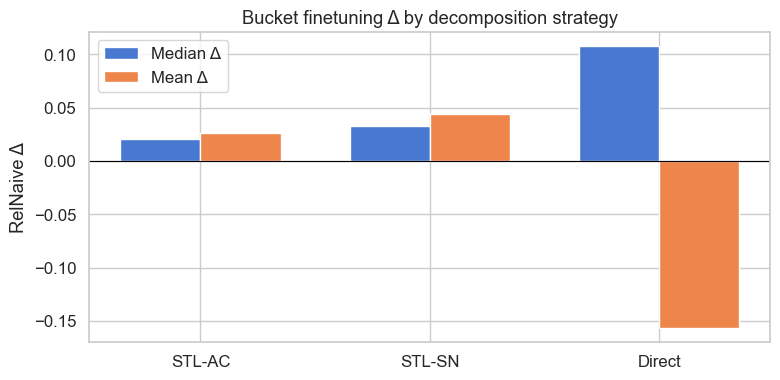

In [8]:
decomp_summary = (
    bkt_delta.groupby("decomposition_method")["rn_delta_ft"]
    .agg(mean="mean", median="median", win_rate=lambda x:(x>0).mean(), n="count")
    .round(4)
)
decomp_summary.index = decomp_summary.index.map(DECOMP_LABELS)
print(decomp_summary.to_string())

fig, ax = plt.subplots(figsize=(8,4))
x = np.arange(3)
for i, metric in enumerate(["median","mean"]):
    ax.bar(x + i*0.35, decomp_summary[metric].values, 0.35,
           label=f"{metric.capitalize()} Δ", edgecolor="white")
ax.set_xticks(x+0.175); ax.set_xticklabels(decomp_summary.index)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Bucket finetuning Δ by decomposition strategy")
ax.set_ylabel("RelNaive Δ"); ax.legend()
fig.tight_layout()
plt.savefig(DATA / "fig_bucket_ft_by_decomp.png", dpi=150, bbox_inches="tight")
plt.show()


## 6  Per-Feature Analysis

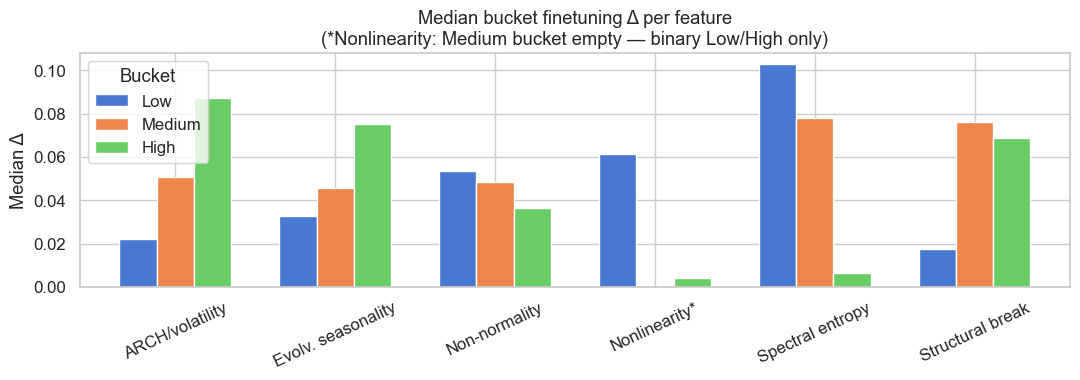

trained_on_bucket      Low  Medium    High
ARCH/volatility     0.0219  0.0509  0.0872
Evolv. seasonality  0.0329  0.0455  0.0753
Non-normality       0.0533  0.0483  0.0364
Nonlinearity*       0.0613     NaN  0.0040
Spectral entropy    0.1030  0.0780  0.0062
Structural break    0.0175  0.0763  0.0688

* Nonlinearity Medium bucket is empty (81-93% exact-zero values → binary distribution).


In [9]:
FEAT_SHORT = {
    "feature_non_normality": "Non-normality",
    "feature_nonlinearity": "Nonlinearity*",
    "feature_spectral_entropy": "Spectral entropy",
    "feature_evolving_seasonality": "Evolv. seasonality",
    "feature_structural_break_strength": "Structural break",
    "feature_arch_stat": "ARCH/volatility",
}
feat_summary = (
    bkt_delta.groupby(["feature_name","trained_on_bucket"])["rn_delta_ft"]
    .agg(median="median", win_rate=lambda x:(x>0).mean()).round(4).reset_index()
)
pivot_feat = feat_summary.pivot(index="feature_name",columns="trained_on_bucket",values="median")
pivot_feat = pivot_feat.reindex(columns=["Low","Medium","High"])
pivot_feat.index = [FEAT_SHORT.get(f,f) for f in pivot_feat.index]
fig, ax = plt.subplots(figsize=(11,4))
pivot_feat.plot(kind="bar", ax=ax, color=[BUCKET_PALETTE[b] for b in pivot_feat.columns],
                edgecolor="white", width=0.7)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Median bucket finetuning Δ per feature\n(*Nonlinearity: Medium bucket empty — binary Low/High only)")
ax.set_xlabel(""); ax.set_ylabel("Median Δ")
ax.tick_params(axis="x", rotation=25); ax.legend(title="Bucket")
fig.tight_layout()
plt.savefig(DATA / "fig_bucket_ft_per_feature.png", dpi=150, bbox_inches="tight")
plt.show()
print(pivot_feat.round(4).to_string())
print("\n* Nonlinearity Medium bucket is empty (81-93% exact-zero values → binary distribution).")


## 7  Statistical Significance — Wilcoxon + Holm

In [10]:
wtest_rows = []
for (fam, model, decomp, bucket), grp in bkt_delta.groupby(
        ["model_family","model_name","decomposition_method","trained_on_bucket"]):
    deltas = grp["rn_delta_ft"].dropna()
    if len(deltas) < 20: continue
    try: stat, p = wilcoxon(deltas)
    except Exception: continue
    wtest_rows.append({
        "family": FAMILY_LABELS.get(fam,fam), "model": model,
        "decomp": DECOMP_LABELS.get(decomp,decomp), "bucket": bucket,
        "n": len(deltas), "median_delta": round(deltas.median(),4),
        "win_rate": round((deltas>0).mean(),3), "p_raw": p,
    })
wdf = pd.DataFrame(wtest_rows)
reject, p_holm, _, _ = multipletests(wdf["p_raw"], method="holm")
wdf["p_holm"] = p_holm.round(4); wdf["significant"] = reject
wdf["verdict"] = wdf.apply(
    lambda r: ("Helps" if r["median_delta"]>0 else "Hurts") if r["significant"] else "Neutral", axis=1)
wdf = wdf.sort_values(["bucket","median_delta"], ascending=[True,False])
sig_help = wdf[(wdf["significant"])&(wdf["median_delta"]>0)]
sig_harm = wdf[(wdf["significant"])&(wdf["median_delta"]<0)]
print(f"Total tests: {len(wdf)}")
print(f"Significantly helps: {len(sig_help)} ({len(sig_help)/len(wdf)*100:.1f}%)")
print(f"Significantly harms: {len(sig_harm)} ({len(sig_harm)/len(wdf)*100:.1f}%)")
print("\nTop 10 improvements:")
print(sig_help.sort_values("median_delta",ascending=False)
      [["family","model","decomp","bucket","median_delta","win_rate","p_holm"]].head(10).to_string(index=False))
print("\nWorst harms:")
print(sig_harm.sort_values("median_delta")
      [["family","model","decomp","bucket","median_delta","win_rate","p_holm"]].head(8).to_string(index=False))
wdf.to_csv(DATA / "table_wilcoxon_bucket_ft.csv", index=False)


Total tests: 81
Significantly helps: 55 (67.9%)
Significantly harms: 23 (28.4%)

Top 10 improvements:
family            model decomp bucket  median_delta  win_rate  p_holm
    ML      AutoXGBoost STL-SN Medium        0.3343     0.723     0.0
    ML      AutoXGBoost STL-AC Medium        0.3083     0.669     0.0
Neural         AutoLSTM STL-SN Medium        0.2989     0.692     0.0
    ML AutoRandomForest STL-AC Medium        0.2912     0.644     0.0
    ML AutoRandomForest STL-SN Medium        0.2899     0.682     0.0
Neural         AutoLSTM STL-AC Medium        0.2865     0.685     0.0
    ML      AutoXGBoost STL-SN    Low        0.2752     0.701     0.0
    ML      AutoXGBoost STL-SN   High        0.2359     0.680     0.0
Neural         AutoLSTM STL-SN    Low        0.2340     0.678     0.0
    ML AutoRandomForest STL-SN    Low        0.2308     0.658     0.0

Worst harms:
family                model decomp bucket  median_delta  win_rate  p_holm
Neural          AutoNLinear STL-AC    Lo

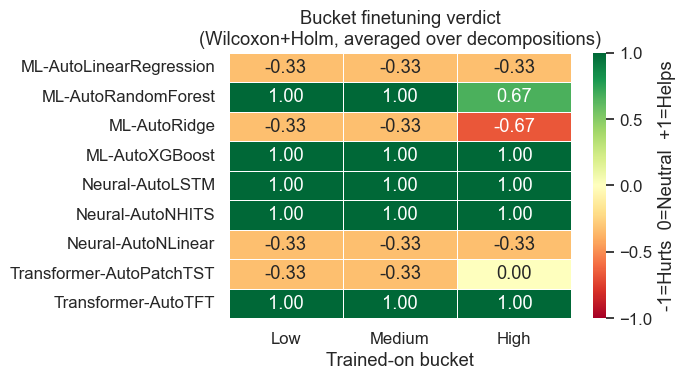

In [11]:
verdict_map = {"Helps":1,"Neutral":0,"Hurts":-1}
wdf["verdict_num"] = wdf["verdict"].map(verdict_map)
pivot_v = wdf.pivot_table(index=["family","model"],columns="bucket",
                           values="verdict_num",aggfunc="mean")
pivot_v = pivot_v.reindex(columns=["Low","Medium","High"])
fig, ax = plt.subplots(figsize=(7, max(4, len(pivot_v)*0.4)))
sns.heatmap(pivot_v, ax=ax, cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.4,
            cbar_kws={"label":"-1=Hurts  0=Neutral  +1=Helps"})
ax.set_title("Bucket finetuning verdict\n(Wilcoxon+Holm, averaged over decompositions)")
ax.set_xlabel("Trained-on bucket"); ax.set_ylabel("")
fig.tight_layout()
plt.savefig(DATA / "fig_wilcoxon_bucket_ft.png", dpi=150, bbox_inches="tight")
plt.show()


## 8  Summary

In [12]:
print("="*60)
print("BUCKET FINETUNING EXECUTIVE SUMMARY")
print("="*60)
d = bkt_delta["rn_delta_ft"]
print(f"Overall: median={d.median():+.4f}  mean={d.mean():+.4f}  win={(d>0).mean()*100:.1f}%")
print("\nBy family:")
for fam, g in bkt_delta.groupby("model_family"):
    dd = g["rn_delta_ft"]
    print(f"  {FAMILY_LABELS.get(fam,fam):<15} median={dd.median():+.4f}  win={(dd>0).mean()*100:.0f}%")
print("\nBy model type:")
for mt, g in bkt_delta.groupby("model_type"):
    dd = g["rn_delta_ft"]
    print(f"  {mt:<12} median={dd.median():+.4f}  win={(dd>0).mean()*100:.0f}%")
print("\nKey takeaways:")
print("  Non-linear models (XGBoost, LSTM, RandomForest) benefit from bucket specialisation.")
print("  Linear models (Ridge, LinearRegression, NLinear) are harmed — small training set")
print("    destabilises coefficient estimation.")
print("  Medium bucket yields the most consistent gains across all families.")
print("  STL-SN paired with bucket finetuning gives the most robust (positive mean+median).")
print("  feature_nonlinearity has no Medium bucket (81-93% exact zeros → binary distribution).")


BUCKET FINETUNING EXECUTIVE SUMMARY
Overall: median=+0.0504  mean=-0.0288  win=56.1%

By family:
  ML              median=+0.0641  win=57%
  Neural          median=+0.0497  win=56%
  Transformer     median=+0.0322  win=55%

By model type:
  Linear       median=-0.0139  win=48%
  Non-linear   median=+0.0920  win=60%

Key takeaways:
  Non-linear models (XGBoost, LSTM, RandomForest) benefit from bucket specialisation.
  Linear models (Ridge, LinearRegression, NLinear) are harmed — small training set
    destabilises coefficient estimation.
  Medium bucket yields the most consistent gains across all families.
  STL-SN paired with bucket finetuning gives the most robust (positive mean+median).
  feature_nonlinearity has no Medium bucket (81-93% exact zeros → binary distribution).
